# Appliance Energy Prediction — Exploratory Data Analysis & Preprocessing

## 1. Load Dataset & Initial Inspection

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/raw/energy_data_set.csv')

# Basic info
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (19735, 29)

Column names:
['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']

Data types:
date            object
Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
dtype: object


## 2. Missing Value Check

In [12]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nSummary statistics:")
df.describe()

Missing values per column:
date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

Summary statistics:


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


## 3. Date Conversion

In [13]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
print(df['date'].min(), "to", df['date'].max())

2016-01-11 17:00:00 to 2016-05-27 18:00:00


## 4. Visualizations — Trend, Distribution & Correlation

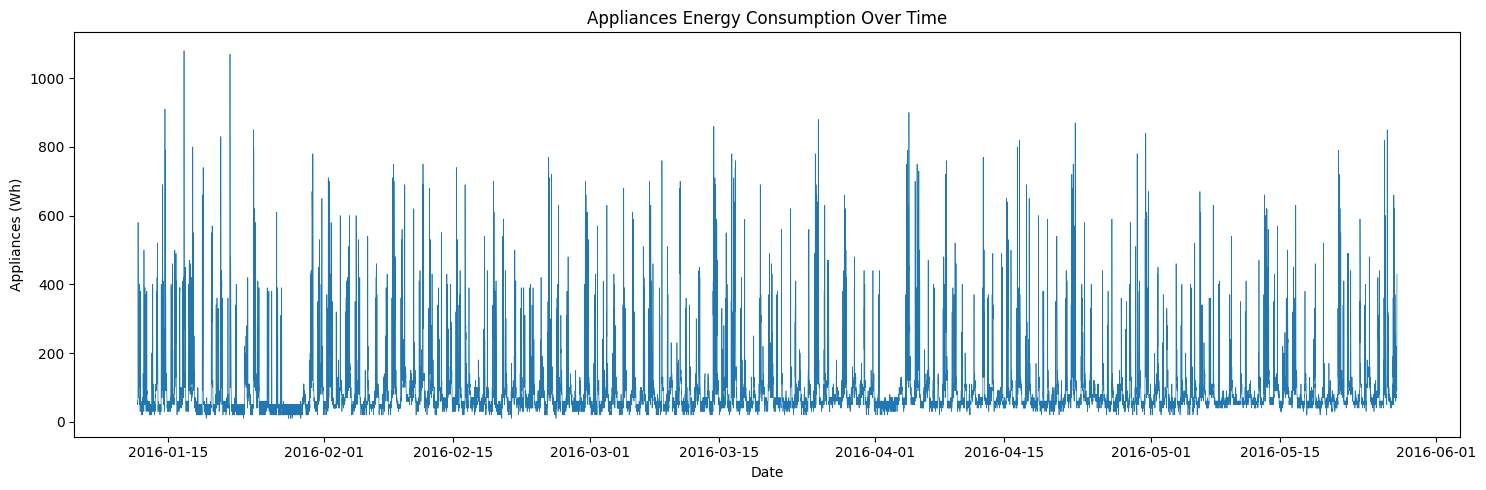

In [14]:
plt.figure(figsize=(15, 5))
plt.plot(df['date'], df['Appliances'], linewidth=0.5)
plt.title('Appliances Energy Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Appliances (Wh)')
plt.tight_layout()
plt.show()

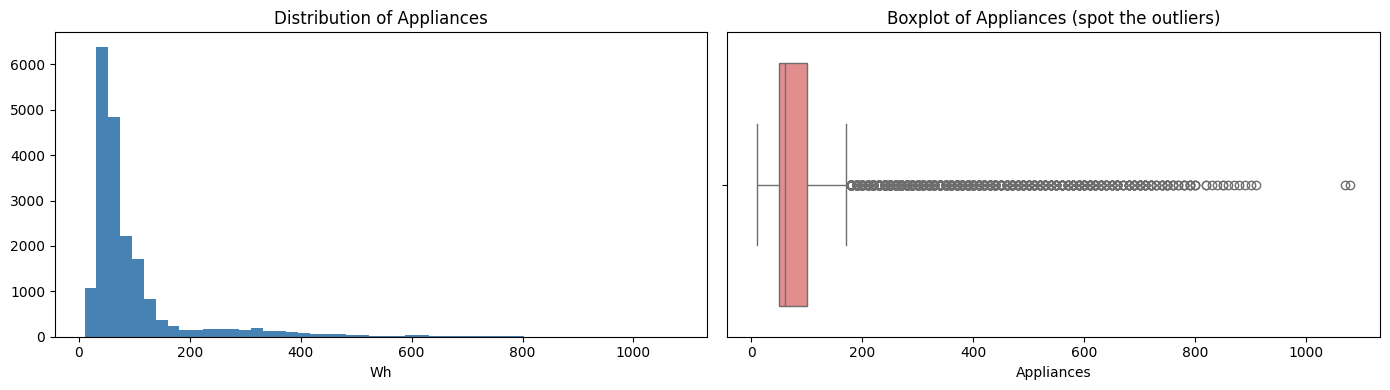

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Appliances'], bins=50, color='steelblue')
axes[0].set_title('Distribution of Appliances')
axes[0].set_xlabel('Wh')

sns.boxplot(x=df['Appliances'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot of Appliances (spot the outliers)')

plt.tight_layout()
plt.show()

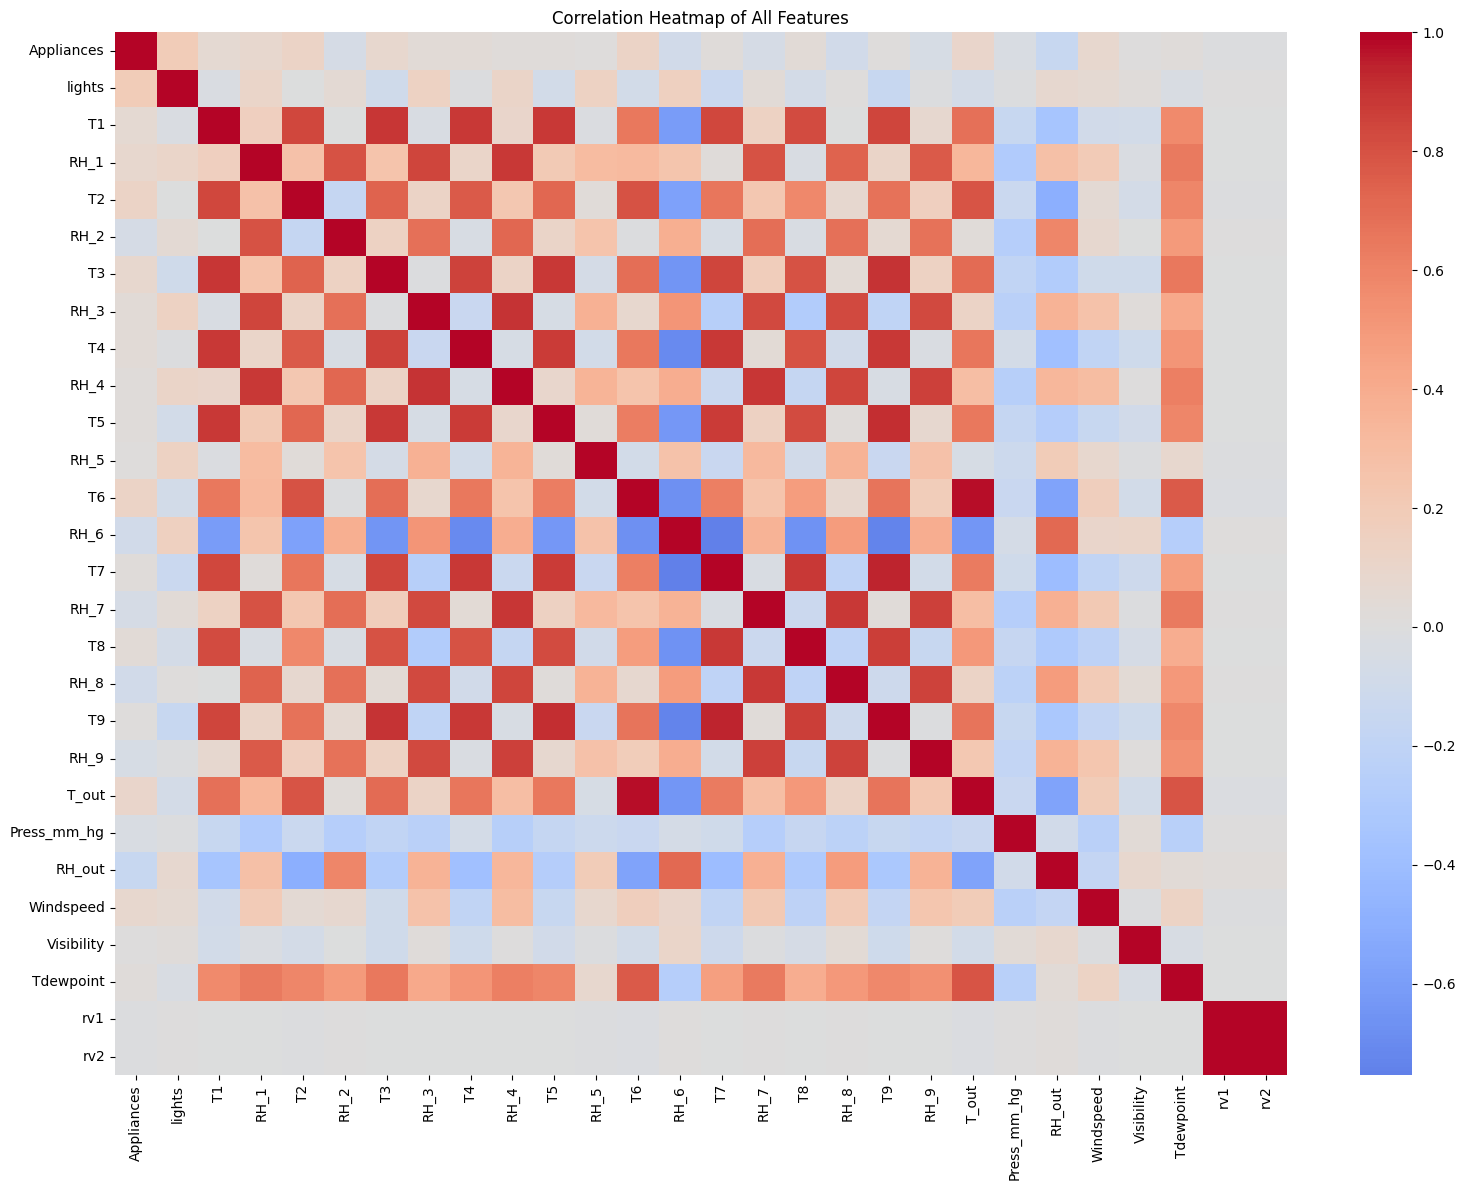

Correlation with Appliances (sorted):
Appliances     1.000000
lights         0.197278
T2             0.120073
T6             0.117638
T_out          0.099155
Windspeed      0.087122
RH_1           0.086031
T3             0.085060
T1             0.055447
T4             0.040281
T8             0.039572
RH_3           0.036292
T7             0.025801
T5             0.019760
RH_4           0.016965
Tdewpoint      0.015353
T9             0.010010
RH_5           0.006955
Visibility     0.000230
rv1           -0.011145
rv2           -0.011145
Press_mm_hg   -0.034885
RH_9          -0.051462
RH_7          -0.055642
RH_2          -0.060465
RH_6          -0.083178
RH_8          -0.094039
RH_out        -0.152282
Name: Appliances, dtype: float64


In [16]:
plt.figure(figsize=(16, 12))
corr = df.drop(columns=['date']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.show()

# Print top correlations with Appliances specifically
print("Correlation with Appliances (sorted):")
print(corr['Appliances'].sort_values(ascending=False))

## 5. Outlier Detection (IQR Method)

Detected 2,138 outliers (10.83%) using the IQR method. Decided to keep them since they represent genuine high-usage appliance events rather than data errors — removing them would hurt the model's ability to predict real consumption spikes.

In [17]:
Q1 = df['Appliances'].quantile(0.25)
Q3 = df['Appliances'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Appliances'] < lower_bound) | (df['Appliances'] > upper_bound)]

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
print(f"Number of outliers: {len(outliers)} out of {len(df)} ({len(outliers)/len(df)*100:.2f}%)")

Q1: 50.0, Q3: 100.0, IQR: 50.0
Lower bound: -25.0, Upper bound: 175.0
Number of outliers: 2138 out of 19735 (10.83%)


## 6. Feature Scaling (Min-Max)

Used Min-Max Scaling instead of Standardization because features have very different natural ranges (temperature, humidity, pressure), and neural networks train more stably with inputs normalized to [0,1].

In [18]:
from sklearn.preprocessing import MinMaxScaler

# Columns we'll scale (all numeric features except the target for now — we'll scale target separately)
feature_cols = [col for col in df.columns if col not in ['date', 'Appliances']]

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

# Scale target separately so we can inverse_transform predictions later
target_scaler = MinMaxScaler()
df_scaled['Appliances'] = target_scaler.fit_transform(df[['Appliances']])

df_scaled.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,0.046729,0.428571,0.32735,0.566187,0.225345,0.684038,0.215188,0.746066,0.351351,...,0.223032,0.677290,0.372990,0.097674,0.894737,0.500000,0.953846,0.538462,0.265449,0.265449
1,2016-01-11 17:10:00,0.046729,0.428571,0.32735,0.541326,0.225345,0.682140,0.215188,0.748871,0.351351,...,0.226500,0.678532,0.369239,0.100000,0.894737,0.476190,0.894872,0.533937,0.372083,0.372083
2,2016-01-11 17:20:00,0.037383,0.428571,0.32735,0.530502,0.225345,0.679445,0.215188,0.755569,0.344745,...,0.219563,0.676049,0.365488,0.102326,0.894737,0.452381,0.835897,0.529412,0.572848,0.572848
3,2016-01-11 17:30:00,0.037383,0.571429,0.32735,0.524080,0.225345,0.678414,0.215188,0.758685,0.341441,...,0.219563,0.671909,0.361736,0.104651,0.894737,0.428571,0.776923,0.524887,0.908261,0.908261
4,2016-01-11 17:40:00,0.046729,0.571429,0.32735,0.531419,0.225345,0.676727,0.215188,0.758685,0.341441,...,0.219563,0.671909,0.357985,0.106977,0.894737,0.404762,0.717949,0.520362,0.201611,0.201611


## 7. Time-Based Train/Test Split & Save Processed Data

In [19]:
split_index = int(len(df_scaled) * 0.8)

train_df = df_scaled.iloc[:split_index]
test_df = df_scaled.iloc[split_index:]

print(f"Train size: {len(train_df)} rows ({train_df['date'].min()} to {train_df['date'].max()})")
print(f"Test size: {len(test_df)} rows ({test_df['date'].min()} to {test_df['date'].max()})")

Train size: 15788 rows (2016-01-11 17:00:00 to 2016-04-30 08:10:00)
Test size: 3947 rows (2016-04-30 08:20:00 to 2016-05-27 18:00:00)


In [20]:
train_df.to_csv('../data/processed/train_scaled.csv', index=False)
test_df.to_csv('../data/processed/test_scaled.csv', index=False)

# Also save the scalers for later use (so we can inverse_transform predictions)
import joblib
joblib.dump(scaler, '../models/feature_scaler.pkl')
joblib.dump(target_scaler, '../models/target_scaler.pkl')

print("Saved train/test sets and scalers.")

Saved train/test sets and scalers.
